[*********************100%***********************]  1 of 1 completed


Price             Close        RSI       SMA_20       EMA_20       MACD
Date                                                                   
2026-02-27  1393.900024  39.981853  1431.105011  1425.617537 -13.120359
2026-03-02  1358.000000  33.667961  1429.485010  1419.177771 -16.949452
2026-03-04  1345.000000  31.714836  1424.880011  1412.113221 -20.793335
2026-03-05  1389.400024  43.722819  1421.510010  1409.950060 -20.026081
2026-03-06  1404.800049  47.191545  1419.580011  1409.459583 -17.968246
2026-03-09  1424.000000  51.227756  1418.240009  1410.844384 -14.619596
2026-03-10  1408.800049  48.093845  1415.600012  1410.649686 -13.041937
2026-03-11  1390.199951  44.505817  1412.185010  1408.702092 -13.141021
2026-03-12  1392.199951  44.981128  1408.360010  1407.130459 -12.909352
2026-03-13  1380.699951  42.715602  1404.950006  1404.613268 -13.498109


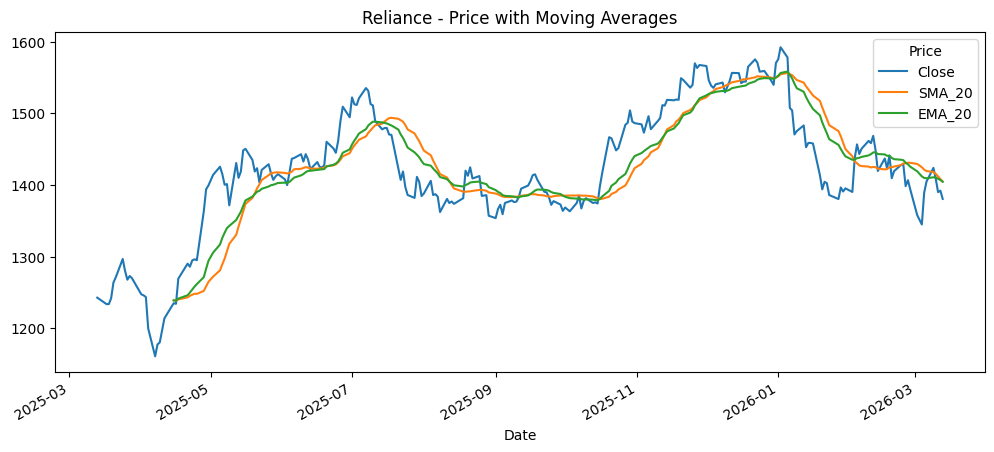

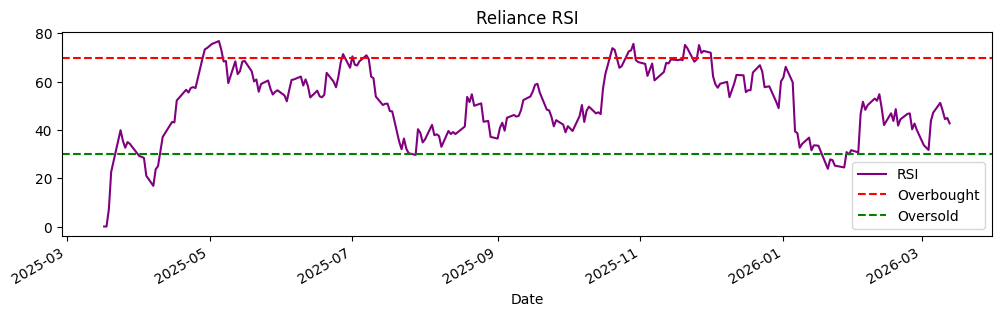

In [3]:
import yfinance as yf
import pandas_ta as ta
import matplotlib.pyplot as plt

# Pick one stock - Reliance
reliance = yf.download("RELIANCE.NS", period="1y")

# Flatten column names if multi-index
reliance.columns = reliance.columns.get_level_values(0)

# Add technical indicators
close = reliance['Close'].squeeze()

reliance['RSI'] = ta.rsi(close, length=14)
reliance['SMA_20'] = ta.sma(close, length=20)
reliance['EMA_20'] = ta.ema(close, length=20)

# MACD manually
reliance['MACD'] = close.ewm(span=12).mean() - close.ewm(span=26).mean()

print(reliance[['Close','RSI','SMA_20','EMA_20','MACD']].tail(10))

# Plot Close price with SMA and EMA
reliance[['Close','SMA_20','EMA_20']].plot(figsize=(12,5), title="Reliance - Price with Moving Averages")
plt.show()

# Plot RSI separately
reliance['RSI'].plot(figsize=(12,3), title="Reliance RSI", color='purple')
plt.axhline(70, color='red', linestyle='--', label='Overbought')
plt.axhline(30, color='green', linestyle='--', label='Oversold')
plt.legend()
plt.show()